In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv('CarPrice_Assignment.csv')
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
data=data.drop(['car_ID','CarName'],axis=1)
data=pd.get_dummies(data, drop_first=True)

In [4]:
x=data.drop('price',axis=1)
y=data['price']

In [5]:
Scaler=StandardScaler()
x = Scaler.fit_transform(x)
y = Scaler.fit_transform(np.array(y).reshape(-1,1))

In [6]:
x_train, x_test, y_train, y_test=train_test_split(x, y,test_size=0.2,random_state=42)

In [7]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)

In [8]:
sgd_model.fit(x_train,y_train)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

In [9]:
y_pred=sgd_model.predict(x_test)

In [10]:
mse=mean_squared_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [11]:
print('Name: a.Jannathul Shaban')
print('Reg.No: 212225220043')
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)
print("R2_Score:",r2score)

Name: a.Jannathul Shaban
Reg.No: 212225220043
Mean Squared Error: 0.21610224135763584
Mean Absolute Error: 0.32154685441108355
R2_Score: 0.8261458258993334


In [12]:
print("\nModel Coefficients")
print("Coefficients:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)


Model Coefficients
Coefficients: [ 0.03669887  0.11172204  0.01605403  0.17530851  0.01866895  0.17138301
  0.2885066  -0.02218157 -0.08198124  0.00056517  0.10410098  0.03657156
 -0.04262829 -0.04915554 -0.02145826  0.02051152  0.01849492 -0.02132122
 -0.08789099 -0.01164385 -0.09206158 -0.03231496  0.06559205  0.2152115
  0.01548284 -0.10340079  0.06822761 -0.01758183  0.00214866  0.00959199
 -0.03429443 -0.14609242 -0.07658642  0.00086425 -0.02950493  0.00959199
 -0.00457147 -0.01616567  0.02145826 -0.01799209 -0.03323215 -0.04092423
 -0.01675642]
Intercept: [-0.01234958]


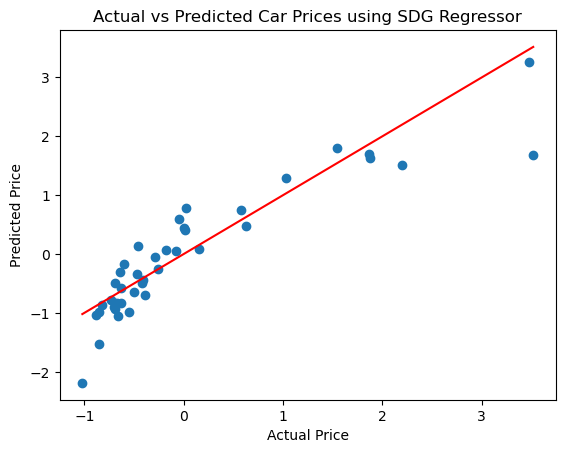

In [13]:
plt.scatter(y_test, y_pred) 
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices using SDG Regressor")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red')
plt.show()